EJERCICIO 6

Simulación dinámica del sistema

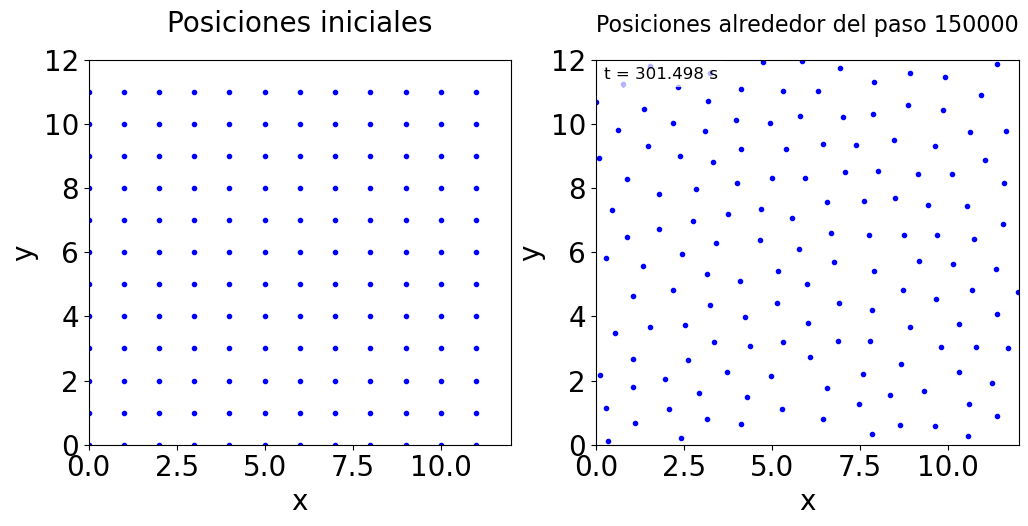

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargo los datos
Posiciones = np.loadtxt("Posiciones_atomos_ej_6.txt")

# Paso temporal
h = 0.002

# Número de frames necesarios para representar 3 segundos completos
N_frames = int(3 / h)  # Esto es igual a 1500 frames

# --- NUEVA LÓGICA PARA CENTRAR EN EL PASO 150000 ---
paso_objetivo = 150000
# Calculamos el rango restando y sumando la mitad de N_frames
inicio_final = paso_objetivo - (N_frames // 2)  # 150000 - 750 = 149250
fin_final = paso_objetivo + (N_frames // 2)     # 150000 + 750 = 150750

# Extraigo los datos iniciales (primeros 3 segundos)
x_inicial = Posiciones[:N_frames, 0::2]
y_inicial = Posiciones[:N_frames, 1::2]

# Extraigo los datos que contienen el paso 150000 (duración de 3 segundos)
x_final = Posiciones[inicio_final:fin_final, 0::2]
y_final = Posiciones[inicio_final:fin_final, 1::2]


# Figura para la simulación
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].set_xlabel("x", fontsize=20)
ax[0].set_ylabel("y", fontsize=20)
ax[0].set_xlim([0, 12])
ax[0].set_ylim([0, 12])
ax[0].set_title("Posiciones iniciales", fontsize=20, pad=20)
ax[0].plot(x_inicial[0, :], y_inicial[0, :], color='blue', marker='o', markersize=3, linestyle='None')
ax[0].tick_params(axis="both", labelsize=20)

ax[1].set_xlabel("x", fontsize=20)
ax[1].set_ylabel("y", fontsize=20)
ax[1].set_xlim([0, 12])
ax[1].set_ylim([0, 12])
ax[1].set_title("Posiciones alrededor del paso 150000", fontsize=16, pad=20)
ax[1].tick_params(axis="both", labelsize=20)

# Creo las líneas que representan cada átomo en la segunda gráfica
line_final, = ax[1].plot([], [], color='blue', marker='o', markersize=3, linestyle='None')

# Creo un texto para mostrar el tiempo en cada frame
tiempo = ax[1].text(0.02, 0.95, "", transform=ax[1].transAxes, fontsize=12, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))


# ************************************** Función de animación *******************************************************
def animate(i):
    # El índice global en el archivo de texto original es el punto de inicio más el frame actual 'i'
    indice_global = inicio_final + i
    
    # El tiempo físico real simulado
    t_final = indice_global * h

    # Actualizamos las posiciones de los átomos para el frame i
    line_final.set_data(x_final[i, :], y_final[i, :])

    # Actualizo el texto del tiempo (el paso 150000 se mostrará exactamente a los t = 300.000 s)
    tiempo.set_text(f"t = {t_final:.3f} s") 

    return line_final, tiempo

# Generamos la animación con los 1500 frames (3 segundos de simulación)
ani = animation.FuncAnimation(fig, animate, frames=N_frames, interval=20, blit=True)

# Guardar la animación
ani.save("animacion_Lennard_Jones_ej_6.gif", writer='pillow', dpi=150)

Energias

In [2]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

#************************Calculo la energia cinetica de las 100 particulas en un tiempo t, por unidad de masa*************

# Extraigo los datos de las posiciones y velocidades de los ficheros
Posiciones = np.loadtxt("posiciones_atomos_ej_6.txt")
Velocidades = np.loadtxt("velocidades_atomos_ej_6.txt")

# Extraigo las velocidades v_x e v_y 
v_x = Velocidades[:, 0::2] # Matriz de 125001 por 100
v_y = Velocidades[:, 1::2]

def energia_cinetica(v_x, v_y):

    v=np.sqrt((v_x)**2+(v_y)**2)
    T_paticula_t=0.5*v**2 #matriz de 125001 por 100, en cada termino energia cinetica de cada particula en distintos tiempos
    T_total=np.sum(T_paticula_t, axis=1) #suma sobre particulas en cada instante
    return T_total #array (125001,)

#***********************Calculo la energia potencial de las 100 particulas en un tiempo t, por unidad de masa*****************

#Defino las matrices de posiciones x e y a partir del fichero posiciones.txt

x = Posiciones[:, 0::2]
y = Posiciones[:, 1::2]

def energia_potencial(x,y): 
    V_t=np.zeros(x.shape) #se inicializa matriz con forma (n_tiempos, n_particulas)

    for i in range(x.shape[1]): 
        for j in range(x.shape[1]):
            if i < j: #evito contar dos veces la misma interaccion

                # Distancias para todos los tiempos entre particula i y j
                dx=np.abs(x[:,i]-x[:,j]) #array (125001, 1)
                dy=np.abs(y[:,i]-y[:,j]) #array (125001,1)


                # Comprobacion elemento a elemento de dx y dy > 11 (condiciones periodicas)
                dx=np.where(dx>11, 22-dx, dx) # where es una funcion de numpy que hace una comprobacion elemento a elemento, si se cumple la condicion dx>11, entonces se asigna el valor 22-dx, y si no se cumple, se asigna el valor dx
                dy=np.where(dy>11, 22-dy, dy)

                rij=np.sqrt(dx**2+dy**2) 

                # Comprobacion elemento a elemento: 0 < rij < 3
                cond=(rij>0) & (rij<3)

                # Solo actualizo donde se cumple la condicion
                V_t[cond,i] = V_t[cond,i] + 4*(1/(rij[cond]**12)-1/(rij[cond]**6))
    V_total_t=np.sum(V_t, axis=1) #energia potencial total en cada instante
    return V_total_t #array (125001,1)

T=energia_cinetica(v_x, v_y)
V=energia_potencial(x,y)

#***********************Energía mecánica******************************************************

E=T+V

# Guardo T, E Y V en un fichero
np.savetxt("Energia_cinetica_potencial_total_ej_6.txt", np.array([T, V, E]).T, header="Energia_cinetica Energia_potencial Energia_total", fmt="%.18e")

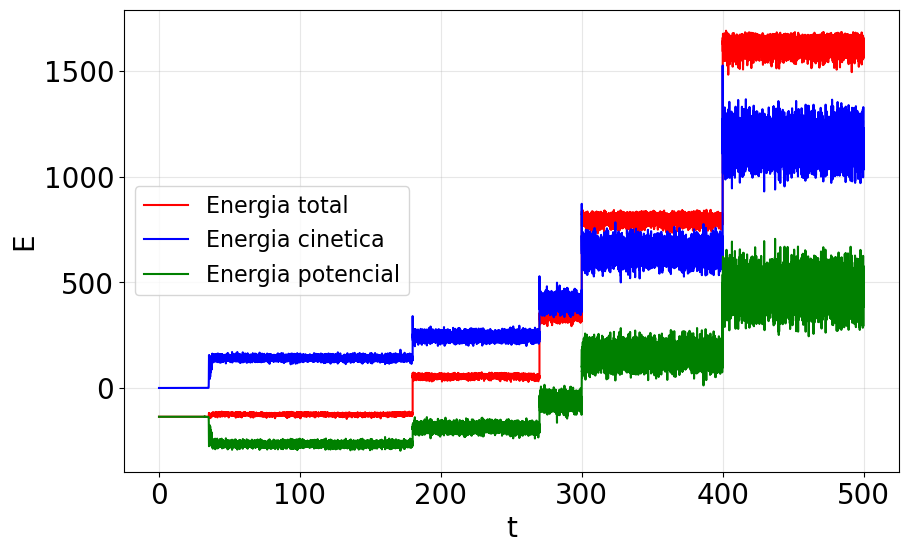

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Represento la energia total del sistema en funcion del tiempo
datos_energia = np.loadtxt("Energia_cinetica_potencial_total_ej_6.txt")



E_t=datos_energia[:, 2]
T_t=datos_energia[:, 0]
V_t=datos_energia[:, 1]

t = np.arange(len(E_t)) * 0.002

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t, E_t, label="Energia total", color="red")
ax.plot(t, T_t, label="Energia cinetica", color="blue")
ax.plot(t, V_t, label="Energia potencial", color="green")
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel("t", fontsize=20)
ax.set_ylabel("E", fontsize=20)

ax.legend(loc="center left", fontsize=16)
ax.grid(alpha=0.3)



fig.savefig("Energia_gas_ej_6.png", dpi=300, bbox_inches="tight")
plt.show()

Evolución de la fluctuaciones de la posición de una partícula cualquiera:

\begin{equation}
\langle (\mathbf{r}(t) - \mathbf{r}(t=0))^2 \rangle
\end{equation}

Se hace una media entre todas las partículas

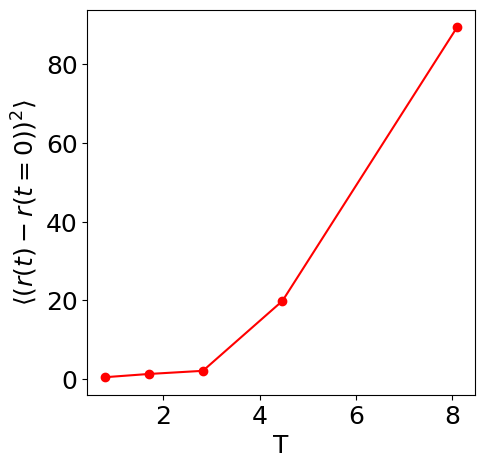

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#Fichero de las velocidades de los atomos y las posiciones sin tener en cuenta las condiciones periodicas

posiciones_sin_c_c = np.loadtxt("Posicion_Atomo_sin_condiciones_periodicas_ej_6.txt")
velocidades = np.loadtxt("Velocidades_Atomos_ej_6.txt")

# Defino el paso temporal y la longitud de la caja
h = 0.002
L = 12.0


# Extraigo las posiciones iniciales de las particulas
x_inicial= posiciones_sin_c_c[0,0::2]
y_inicial= posiciones_sin_c_c[0,1::2]


dx=posiciones_sin_c_c[:,0::2]-x_inicial
dy=posiciones_sin_c_c[:,1::2]-y_inicial


# Calculo r^2, que es una matriz de 250001 filas y 144 columnas
r_cuadrado = dx**2 + dy**2

#Realizo los promedios para cada instante de tiempo, entre todas las particulas

r_cuadrado_particulas = np.mean(r_cuadrado, axis = 1) # vector de 250001 elementos

# Realizo los promedios en los intervalos de tiempo correspondientes a los reescalados de las velocidades, es decir, a t = 180, 270, 300 y 400 segundos

r_cuadrado_0 = np.mean(r_cuadrado_particulas[:90000])
r_cuadrado_180 = np.mean(r_cuadrado_particulas[90000:135000])
r_cuadrado_270 = np.mean(r_cuadrado_particulas[135000:150000])
r_cuadrado_300 = np.mean(r_cuadrado_particulas[150000:200000])
r_cuadrado_400 = np.mean(r_cuadrado_particulas[200000:])

# Almaceno en un array 
r_cuadrado_medio = np.array([r_cuadrado_0, r_cuadrado_180, r_cuadrado_270, r_cuadrado_300, r_cuadrado_400])

# Extraigo las velocidades v_x e v_y de los átomos
v_x = velocidades[1:, 0::2]
v_y = velocidades[1:, 1::2]

# Hago la media sobre las columnas, es decir, sobre los átomos, para obtener la temperatura en cada instante de tiempo 
T = 0.5 * np.mean(v_x**2 + v_y**2, axis = 1)

# Hago la media sobre los intervalos de tiempo correspondientes a los reescalados de las velocidades, es decir, a t = 180, 270, 300 y 400 segundos
T_0 = np.mean(T[:90000])
T_180 = np.mean(T[90000:135000])
T_270 = np.mean(T[135000:150000])
T_300 = np.mean(T[150000:200000])
T_400 = np.mean(T[200000:])

# Almaceno en un array
T_medio = np.array([T_0, T_180, T_270, T_300, T_400])

# Grafico la evolución de r_cuadrado en función de la temperatura
fig, ax = plt.subplots(figsize=(5, 5))

# Grafico la evolución de r_cuadrado en función de la temperatura T
ax.plot(T_medio, r_cuadrado_medio, marker = "o", color = 'red')
ax.set_xlabel("T", fontsize=18)
ax.set_ylabel(r"$\langle(r(t) - r(t=0))^2 \rangle$", fontsize=18)
ax.tick_params(axis="both", labelsize=18)

fig.savefig("r_vs_t_ej_6.png", dpi = 150, bbox_inches="tight")
plt.show()